In [1]:
import pandas as pd 
import seaborn as sns


In [2]:
df = pd.read_csv(r"C:\Users\DELL\OneDrive\Documents\Machine Learning\Customer Churn\ChurnModelling.csv")
df.head(3)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


In [3]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'Geography', 'Gender'], inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Age              10000 non-null  int64  
 2   Tenure           10000 non-null  int64  
 3   Balance          10000 non-null  float64
 4   NumOfProducts    10000 non-null  int64  
 5   HasCrCard        10000 non-null  int64  
 6   IsActiveMember   10000 non-null  int64  
 7   EstimatedSalary  10000 non-null  float64
 8   Exited           10000 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 703.2 KB


In [7]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


<Axes: ylabel='CreditScore'>

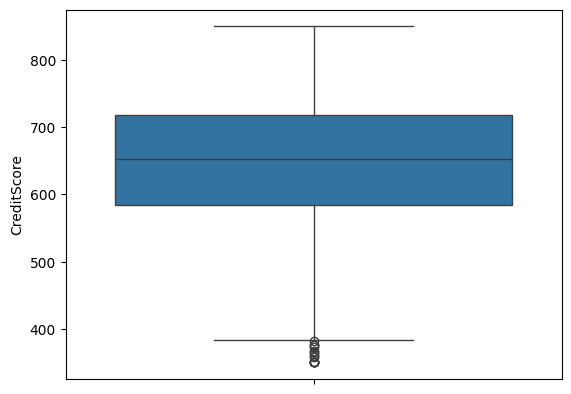

In [8]:
sns.boxplot(data=df, y="CreditScore")

In [9]:
df["CreditScore"].describe()

count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: CreditScore, dtype: float64

In [10]:
q1 = 584.00
q3 = 718.00
IQR = q3 - q1
lb = q1 - 1.5*IQR
ub = q3 + 1.5*IQR 

<Axes: ylabel='CreditScore'>

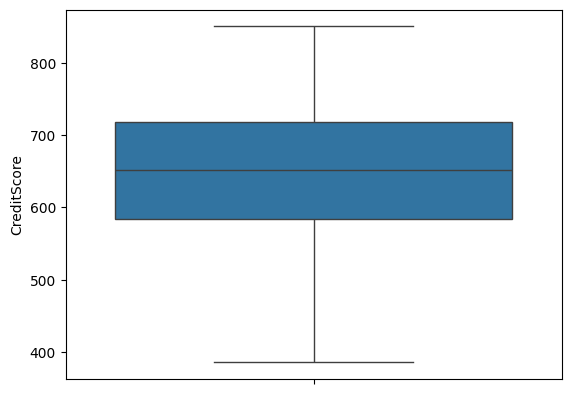

In [11]:
df = df[(df["CreditScore"]>lb)&(df["CreditScore"]<ub)]
sns.boxplot(data=df, y="CreditScore")

<Axes: ylabel='Age'>

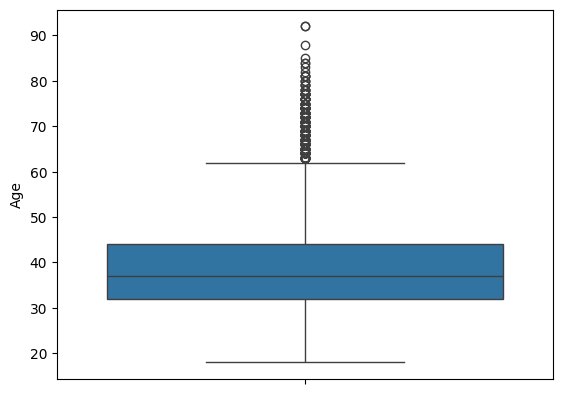

In [12]:
sns.boxplot(data=df, y="Age")

In [13]:
df["Age"].describe()

count    9984.000000
mean       38.914263
std        10.487614
min        18.000000
25%        32.000000
50%        37.000000
75%        44.000000
max        92.000000
Name: Age, dtype: float64

In [14]:
q1 = 32.0
q3 = 44.0
IQR = q3 - q1
lb = q1 - 1.5*IQR
ub = q3 + 1.5*IQR

<Axes: ylabel='Age'>

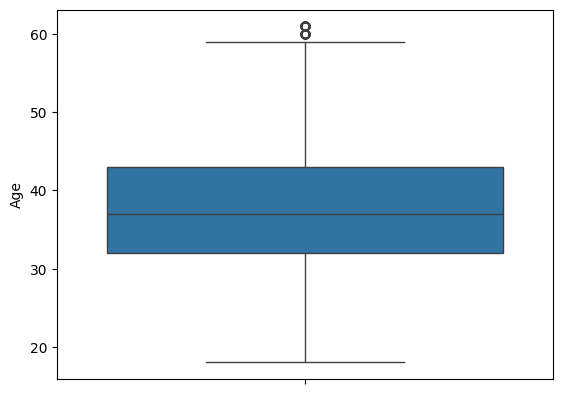

In [15]:
df = df[(df["Age"]>lb)&(df["Age"]<ub)]
sns.boxplot(data=df, y="Age")

<Axes: ylabel='EstimatedSalary'>

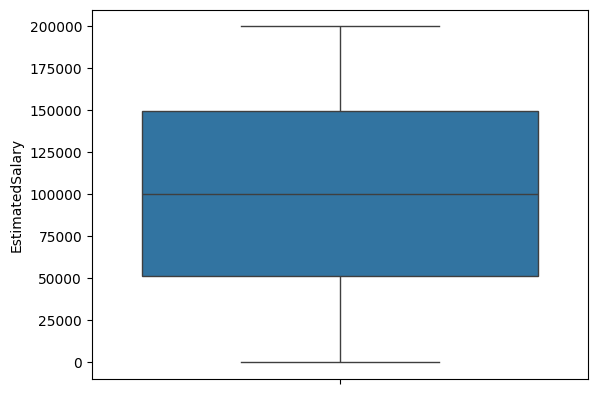

In [16]:
sns.boxplot(data=df, y="EstimatedSalary")

In [17]:
X = df.drop(columns=['Exited'])
y = df['Exited']                


In [18]:
from sklearn.model_selection import train_test_split
X_train,  X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
from sklearn.linear_model import LogisticRegression
log = LogisticRegression()

In [20]:
log.fit(X_train, y_train)

c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [21]:
y_pred = log.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy_score(y_test, y_pred)

0.8135770234986945

In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.98      0.89      1540
           1       0.60      0.15      0.24       375

    accuracy                           0.81      1915
   macro avg       0.71      0.56      0.57      1915
weighted avg       0.78      0.81      0.77      1915



In [24]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)

In [25]:
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [26]:
y_pred1 = knn.predict(X_test)
y_pred1

array([0, 1, 0, ..., 0, 0, 0], shape=(1915,))

In [27]:
accuracy_score(y_test, y_pred1)

0.7691906005221932

In [28]:
print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           0       0.81      0.94      0.87      1540
           1       0.24      0.08      0.12       375

    accuracy                           0.77      1915
   macro avg       0.52      0.51      0.49      1915
weighted avg       0.70      0.77      0.72      1915



In [29]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier()

In [30]:
dtc.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [31]:
y_pred2 = dtc.predict(X_test)
y_pred2

array([0, 0, 1, ..., 1, 0, 1], shape=(1915,))

In [32]:
accuracy_score(y_test, y_pred2)

0.787467362924282

In [33]:
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       0.88      0.85      0.87      1540
           1       0.46      0.53      0.49       375

    accuracy                           0.79      1915
   macro avg       0.67      0.69      0.68      1915
weighted avg       0.80      0.79      0.79      1915



In [36]:
from xgboost import XGBClassifier

In [37]:
xgb = XGBClassifier()

In [38]:
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [40]:
y_pred3 = xgb.predict(X_test)
y_pred3

array([1, 0, 1, ..., 1, 1, 0], shape=(1915,))

In [41]:
accuracy_score(y_test, y_pred3)

0.8433420365535248

In [43]:
print(classification_report(y_test, y_pred3))

              precision    recall  f1-score   support

           0       0.88      0.94      0.91      1540
           1       0.64      0.46      0.54       375

    accuracy                           0.84      1915
   macro avg       0.76      0.70      0.72      1915
weighted avg       0.83      0.84      0.83      1915



In [44]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)

In [45]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [47]:
y_pred4 = rf.predict(X_test)
y_pred4

array([1, 0, 1, ..., 1, 0, 0], shape=(1915,))

In [48]:
accuracy_score(y_test, y_pred4)

0.856396866840731

In [49]:
print(classification_report(y_test, y_pred4))

              precision    recall  f1-score   support

           0       0.88      0.96      0.91      1540
           1       0.72      0.44      0.55       375

    accuracy                           0.86      1915
   macro avg       0.80      0.70      0.73      1915
weighted avg       0.84      0.86      0.84      1915

